In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import warnings
from scipy.stats import chi2

/Users/felipetapanesgonzalez/Documents/Varsity/Masters/MSc_Thesis_Python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df = pd.read_csv("../data/processed/master_atc_trolley_eda_adjusted.csv")
df["YEAR_MONTH"] = pd.to_datetime(df["YEAR_MONTH"])
df = df.set_index("YEAR_MONTH").asfreq("MS")


In [3]:
series = df["Monthly_Trolley_Total"]
series.head()

YEAR_MONTH
2016-01-01    7537
2016-02-01    6825
2016-03-01    7018
2016-04-01    6211
2016-05-01    5117
Freq: MS, Name: Monthly_Trolley_Total, dtype: int64

In [4]:
series.isna().sum()

0

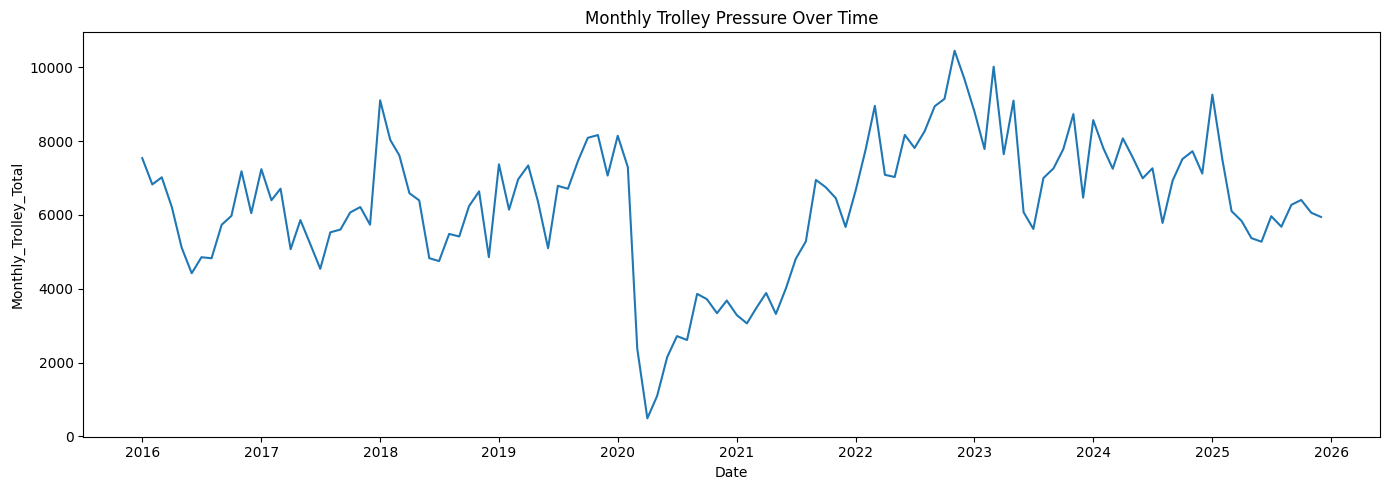

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(series.index, series.values)
plt.title("Monthly Trolley Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly_Trolley_Total")
plt.tight_layout()
plt.show()

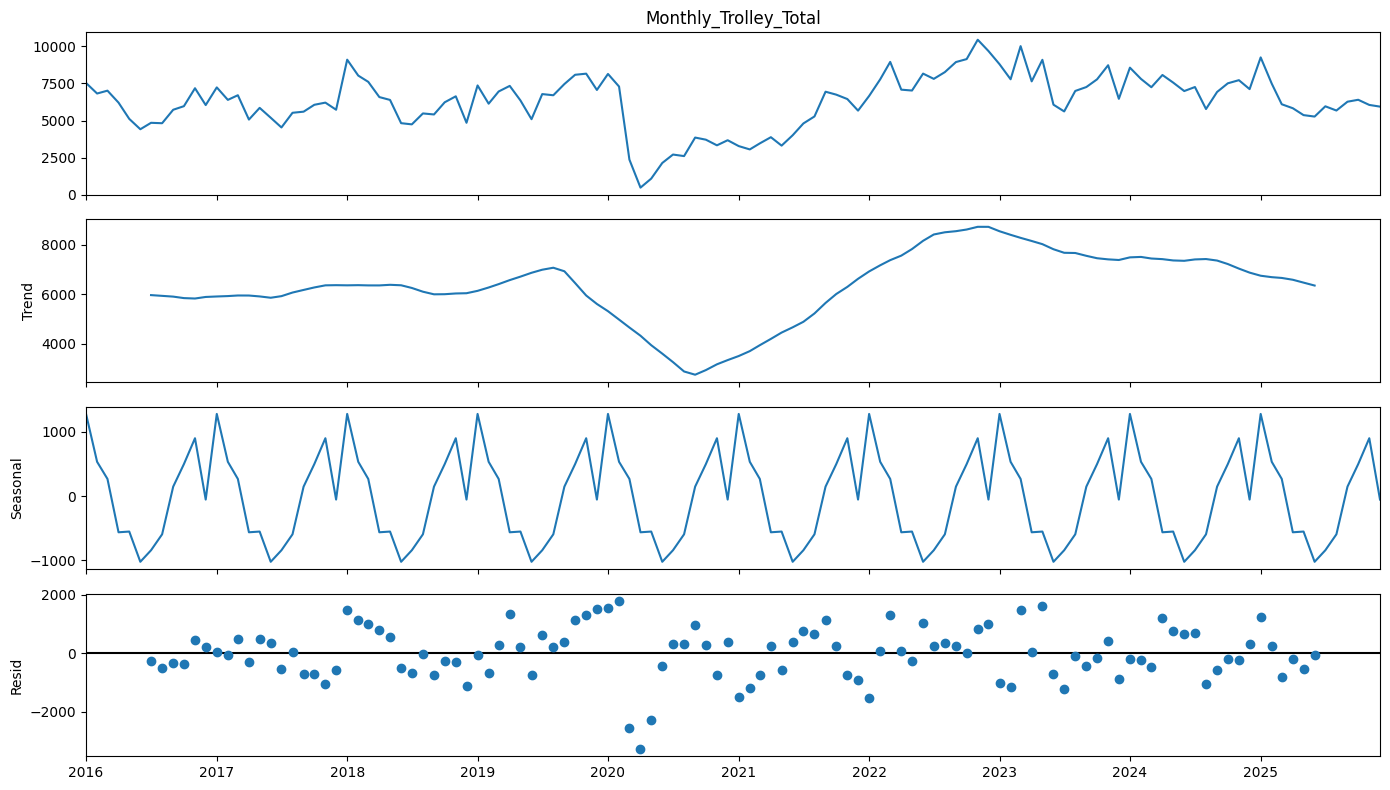

In [6]:
decomposition = seasonal_decompose(series, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

In [7]:
result = adfuller(series.dropna())
print("statistic:", result[0])
print("p-value:", result[1])
print("critical values:", result[4])

statistic: -3.6022095729000263
p-value: 0.005718925692425136
critical values: {'1%': -3.4865346059036564, '5%': -2.8861509858476264, '10%': -2.579896092790057}


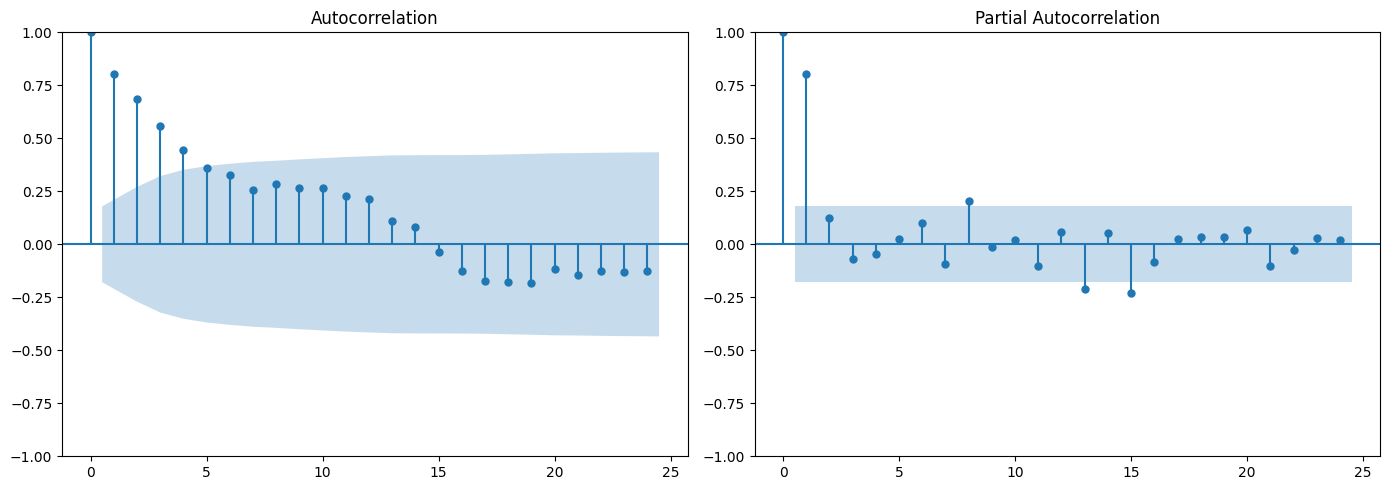

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(series, lags=24, ax=axes[0])
plot_pacf(series, lags=24, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

In [9]:

pacf_vals, confint = pacf(series, nlags=24, alpha=0.05, method="ywm")

for lag in range(6):
    lower, upper = confint[lag]
    significant = pacf_vals[lag] > upper - pacf_vals[lag] or pacf_vals[lag] < lower - pacf_vals[lag]
    print(f"lag {lag}: value={pacf_vals[lag]:.3f}")

lag 0: value=1.000
lag 1: value=0.802
lag 2: value=0.125
lag 3: value=-0.070
lag 4: value=-0.044
lag 5: value=0.023


In [10]:
n_test = 12
train = series[:-n_test]
test = series[-n_test:]

print("train range:", train.index.min(), "to", train.index.max())
print("test range:", test.index.min(), "to", test.index.max())

train range: 2016-01-01 00:00:00 to 2024-12-01 00:00:00
test range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00


### COVID interpolation toggle

Set `APPLY_COVID_SMOOTHING = True` below and re-run everything downstream to test model results with the COVID dip (Mar-Aug 2020) smoothed out. Set it back to `False` and re-run to restore the original data.

In [11]:
APPLY_COVID_SMOOTHING = False 

if APPLY_COVID_SMOOTHING:
    train = series[:-n_test].copy()
    train["2020-03-01":"2020-08-01"] = np.nan
    train = train.interpolate(method="linear")
else:
    train = series[:-n_test].copy()

print("COVID smoothing applied:", APPLY_COVID_SMOOTHING)
train["2020-01-01":"2020-12-01"]


COVID smoothing applied: False


YEAR_MONTH
2020-01-01    8143
2020-02-01    7295
2020-03-01    2375
2020-04-01     489
2020-05-01    1095
2020-06-01    2149
2020-07-01    2716
2020-08-01    2612
2020-09-01    3860
2020-10-01    3717
2020-11-01    3337
2020-12-01    3680
Freq: MS, Name: Monthly_Trolley_Total, dtype: int64

In [12]:
model_arima = ARIMA(train, order=(1, 0, 0))
fit_arima = model_arima.fit()
print(fit_arima.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                  108
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -910.551
Date:                   Thu, 23 Jul 2026   AIC                           1827.102
Time:                           22:34:51   BIC                           1835.149
Sample:                       01-01-2016   HQIC                          1830.365
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6301.7037    560.752     11.238      0.000    5202.650    7400.758
ar.L1          0.8059      0.062     13.013      0.000       0.685       0.927
sigma2      1.226e+06   1.14

In [13]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [14]:
auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.25 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2207.466, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1838.306, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2096.436, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1836.063, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1837.929, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1838.087, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=2020.236, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1827.779, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1882.299, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1827.099, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1939.827, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1827.437, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1

In [15]:
auto_sarima = auto_arima(
    train,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)
print(auto_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1939.827, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1825.549, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1875.417, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2207.466, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1827.099, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1827.480, Time=1.31 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1827.479, Time=0.45 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1825.790, Time=0.04 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=1828.808, Time=0.82 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=1941.432, Time=0.02 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=1826.289, Time=0.06 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=1826.739, Time=0.07 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=1882.625, Time=0.07 sec
 ARIMA(2,0,1)(1,0,0)[12]

Change fit_arima.forecast(steps=n_test) to auto_model.predict(n_periods=n_test) if smoothing is true

In [16]:
forecast_arima = np.asarray(fit_arima.forecast(steps=n_test))
forecast_sarima = np.asarray(auto_sarima.predict(n_periods=n_test))

rmse_arima = np.sqrt(np.mean((test.values - forecast_arima) ** 2))
rmse_sarima = np.sqrt(np.mean((test.values - forecast_sarima) ** 2))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)


ARIMA RMSE: 955.0250498705801
SARIMA RMSE: 1010.3438439443836


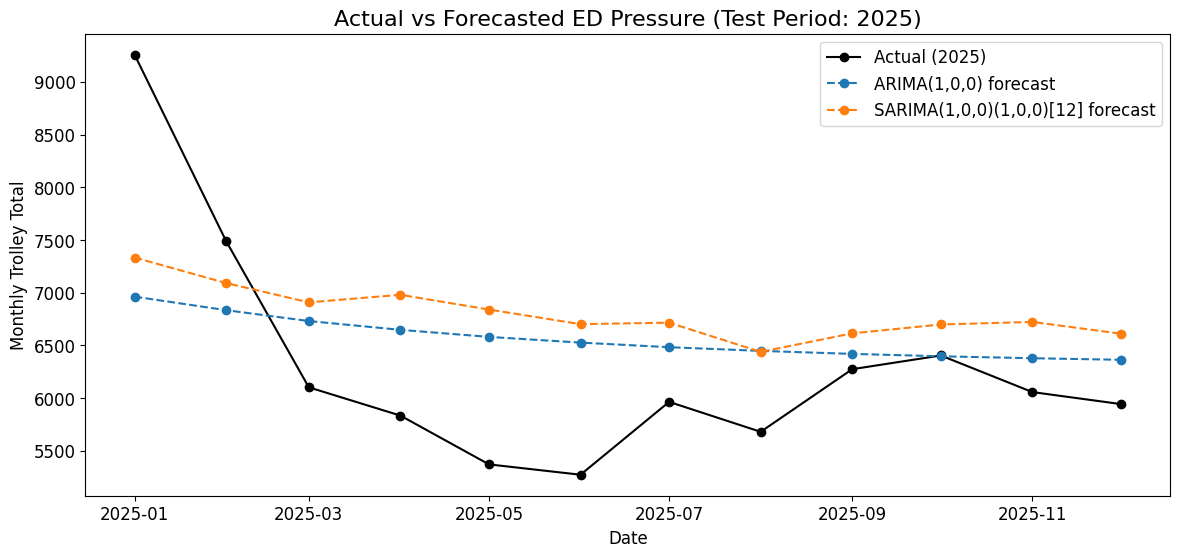

In [42]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, label="Actual (2025)", color="black", marker="o")
plt.plot(test.index, forecast_arima, label="ARIMA(1,0,0) forecast", linestyle="--", marker="o")
plt.plot(test.index, forecast_sarima, label="SARIMA(1,0,0)(1,0,0)[12] forecast", linestyle="--", marker="o")
plt.title("Actual vs Forecasted ED Pressure (Test Period: 2025)")
plt.xlabel("Date")
plt.ylabel("Monthly Trolley Total")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
})
plt.legend()
plt.show()


In [18]:
naive_mean_forecast = np.full(n_test, train.mean())
naive_persist_forecast = np.full(n_test, train.iloc[-1])

rmse_naive_mean = np.sqrt(np.mean((test.values - naive_mean_forecast) ** 2))
rmse_naive_persist = np.sqrt(np.mean((test.values - naive_persist_forecast) ** 2))

print("Naive (predict average) RMSE:", rmse_naive_mean)
print("Naive (predict no change) RMSE:", rmse_naive_persist)
print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)


Naive (predict average) RMSE: 1041.9075964994913
Naive (predict no change) RMSE: 1324.0298964399055
ARIMA RMSE: 955.0250498705801
SARIMA RMSE: 1010.3438439443836


In [19]:
exog_full = pd.DataFrame({
    "S03_lag1": df["S03"].shift(1),
    "J01_lag1": df["J01"].shift(1),
})

exog_train_raw = exog_full.loc[train.index]
exog_test_raw = exog_full.loc[test.index]

exog_mean = exog_train_raw.mean()
exog_std = exog_train_raw.std()

exog_train = (exog_train_raw - exog_mean) / exog_std
exog_test = (exog_test_raw - exog_mean) / exog_std

valid_idx = exog_train.dropna().index
exog_train = exog_train.loc[valid_idx]
train_aligned = train.loc[valid_idx]

print(exog_train.shape, train_aligned.shape)
exog_train.head()


(107, 2) (107,)


,S03_lag1,J01_lag1
YEAR_MONTH,,
2016-02-01,0.365207,2.071744
2016-03-01,0.542556,1.608082
2016-04-01,0.529172,1.377019
2016-05-01,0.521364,0.557925
2016-06-01,0.331745,0.233056


In [20]:
model_arimax_lag1 = ARIMA(train_aligned, exog=exog_train, order=(1, 0, 0))
fit_arimax_lag1 = model_arimax_lag1.fit()
print(fit_arimax_lag1.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                  107
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -901.447
Date:                   Thu, 23 Jul 2026   AIC                           1812.895
Time:                           22:34:57   BIC                           1826.259
Sample:                       02-01-2016   HQIC                          1818.312
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6298.7010    764.560      8.238      0.000    4800.191    7797.211
S03_lag1    -278.5236    250.267     -1.113      0.266    -769.038     211.991
J01_lag1     167.4836    188

In [21]:
forecast_arimax_lag1 = np.asarray(fit_arimax_lag1.forecast(steps=n_test, exog=exog_test))
rmse_arimax_lag1 = np.sqrt(np.mean((test.values - forecast_arimax_lag1) ** 2))
print("ARIMAX (S03+J01 @ lag1) RMSE:", rmse_arimax_lag1)
print("ARIMA baseline RMSE:", rmse_arima)


ARIMAX (S03+J01 @ lag1) RMSE: 932.1168692185872
ARIMA baseline RMSE: 955.0250498705801


In [22]:
model_arima_aligned = ARIMA(train_aligned, order=(1, 0, 0))
fit_arima_aligned = model_arima_aligned.fit()

llf_baseline = fit_arima_aligned.llf
llf_arimax = fit_arimax_lag1.llf

lr_stat = 2 * (llf_arimax - llf_baseline)
p_value = chi2.sf(lr_stat, df=2)

print("baseline log-likelihood:", llf_baseline)
print("ARIMAX log-likelihood:", llf_arimax)
print("LR statistic:", lr_stat)
print("p-value:", p_value)


baseline log-likelihood: -902.3561153740853
ARIMAX log-likelihood: -901.4473343864383
LR statistic: 1.8175619752939838
p-value: 0.40301520523039036


In [23]:
exog_full_lag0 = df[["S03", "J01"]].copy()

exog_train_lag0_raw = exog_full_lag0.loc[train.index]
exog_test_lag0_raw = exog_full_lag0.loc[test.index]

exog_mean_lag0 = exog_train_lag0_raw.mean()
exog_std_lag0 = exog_train_lag0_raw.std()

exog_train_lag0 = (exog_train_lag0_raw - exog_mean_lag0) / exog_std_lag0
exog_test_lag0 = (exog_test_lag0_raw - exog_mean_lag0) / exog_std_lag0

print(exog_train_lag0.shape, exog_test_lag0.shape)
exog_train_lag0.head()


(108, 2) (12, 2)


,S03,J01
YEAR_MONTH,,
2016-01-01,0.358397,2.022131
2016-02-01,0.536049,1.565345
2016-03-01,0.522641,1.337710
2016-04-01,0.514820,0.530765
2016-05-01,0.324878,0.210715


In [24]:
model_arimax_lag0 = ARIMA(train, exog=exog_train_lag0, order=(1, 0, 0))
fit_arimax_lag0 = model_arimax_lag0.fit()
print(fit_arimax_lag0.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                  108
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -886.925
Date:                   Thu, 23 Jul 2026   AIC                           1783.850
Time:                           22:34:57   BIC                           1797.261
Sample:                       01-01-2016   HQIC                          1789.287
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6297.7521    369.724     17.034      0.000    5573.106    7022.399
S03          962.9803    102.902      9.358      0.000     761.297    1164.664
J01          206.9243    132

In [25]:
forecast_arimax_lag0 = np.asarray(fit_arimax_lag0.forecast(steps=n_test, exog=exog_test_lag0))
rmse_arimax_lag0 = np.sqrt(np.mean((test.values - forecast_arimax_lag0) ** 2))

lr_stat_lag0 = 2 * (fit_arimax_lag0.llf - fit_arima.llf)
p_value_lag0 = chi2.sf(lr_stat_lag0, df=2)

print("ARIMAX (S03+J01 @ lag0) RMSE:", rmse_arimax_lag0)
print("ARIMA baseline RMSE:", rmse_arima)
print("LR statistic:", lr_stat_lag0)
print("p-value:", p_value_lag0)

ARIMAX (S03+J01 @ lag0) RMSE: 886.9311683211728
ARIMA baseline RMSE: 955.0250498705801
LR statistic: 47.252501710074284
p-value: 5.4859219643003977e-11


In [26]:
exog_full_lag6 = pd.DataFrame({
    "G03_lag6": df["G03"].shift(6),
    "C05_lag6": df["C05"].shift(6),
    "P01_lag6": df["P01"].shift(6),
})

exog_train_lag6_raw = exog_full_lag6.loc[train.index]
exog_test_lag6_raw = exog_full_lag6.loc[test.index]

exog_mean_lag6 = exog_train_lag6_raw.mean()
exog_std_lag6 = exog_train_lag6_raw.std()

exog_train_lag6 = (exog_train_lag6_raw - exog_mean_lag6) / exog_std_lag6
exog_test_lag6 = (exog_test_lag6_raw - exog_mean_lag6) / exog_std_lag6

valid_idx_lag6 = exog_train_lag6.dropna().index
exog_train_lag6 = exog_train_lag6.loc[valid_idx_lag6]
train_aligned_lag6 = train.loc[valid_idx_lag6]

print(exog_train_lag6.shape, train_aligned_lag6.shape)
exog_train_lag6.head()


(102, 3) (102,)


,G03_lag6,C05_lag6,P01_lag6
YEAR_MONTH,,,
2016-07-01,-0.337781,0.135920,-0.918200
2016-08-01,-0.465686,-0.056793,-1.082844
2016-09-01,-0.036832,0.217894,-0.204739
2016-10-01,-0.010876,0.853558,-0.744093
2016-11-01,-0.012857,0.419236,-0.367491


In [27]:
model_arimax_lag6 = ARIMA(train_aligned_lag6, exog=exog_train_lag6, order=(1, 0, 0))
fit_arimax_lag6 = model_arimax_lag6.fit()
print(fit_arimax_lag6.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                  102
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -857.613
Date:                   Thu, 23 Jul 2026   AIC                           1727.225
Time:                           22:34:57   BIC                           1742.975
Sample:                       07-01-2016   HQIC                          1733.603
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6305.2764    430.564     14.644      0.000    5461.387    7149.166
G03_lag6     869.1015    499.604      1.740      0.082    -110.104    1848.307
C05_lag6     114.8303    205

In [28]:
model_arima_aligned6 = ARIMA(train_aligned_lag6, order=(1, 0, 0))
fit_arima_aligned6 = model_arima_aligned6.fit()

lr_stat_lag6 = 2 * (fit_arimax_lag6.llf - fit_arima_aligned6.llf)
p_value_lag6 = chi2.sf(lr_stat_lag6, df=3)

forecast_arimax_lag6 = np.asarray(fit_arimax_lag6.forecast(steps=n_test, exog=exog_test_lag6))
rmse_arimax_lag6 = np.sqrt(np.mean((test.values - forecast_arimax_lag6) ** 2))

print("LR statistic:", lr_stat_lag6)
print("p-value:", p_value_lag6)
print("ARIMAX (G03+C05+P01 @ lag6) RMSE:", rmse_arimax_lag6)
print("ARIMA baseline RMSE:", rmse_arima)


LR statistic: 8.517861702966911
p-value: 0.03643793893434362
ARIMAX (G03+C05+P01 @ lag6) RMSE: 2053.0116458739412
ARIMA baseline RMSE: 955.0250498705801


In [29]:
benzo_df = pd.read_csv("../data/processed/master_benzo_trolley_eda_adjusted.csv")
benzo_df["YEAR_MONTH"] = pd.to_datetime(benzo_df["YEAR_MONTH"])
benzo_df = benzo_df.set_index("YEAR_MONTH").asfreq("MS")

n05cd02 = benzo_df["BENZO_FREQ_N05CD02"]
n05cd02.shape

(96,)

In [30]:
exog_full_n05 = pd.DataFrame({
    "N05CD02_lag5": n05cd02.shift(5)
})

exog_train_n05_raw = exog_full_n05.reindex(train.index)
exog_test_n05_raw = exog_full_n05.reindex(test.index)

exog_mean_n05 = exog_train_n05_raw.mean()
exog_std_n05 = exog_train_n05_raw.std()

exog_train_n05 = (exog_train_n05_raw - exog_mean_n05) / exog_std_n05
exog_test_n05 = (exog_test_n05_raw - exog_mean_n05) / exog_std_n05

valid_idx_n05 = exog_train_n05.dropna().index
exog_train_n05 = exog_train_n05.loc[valid_idx_n05]
train_aligned_n05 = train.loc[valid_idx_n05]

print(exog_train_n05.shape, train_aligned_n05.shape)
print("usable range:", exog_train_n05.index.min(), "to", exog_train_n05.index.max())


(79, 1) (79,)
usable range: 2018-06-01 00:00:00 to 2024-12-01 00:00:00


In [31]:
model_arimax_n05 = ARIMA(train_aligned_n05, exog=exog_train_n05, order=(1, 0, 0))
fit_arimax_n05 = model_arimax_n05.fit()
print(fit_arimax_n05.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                   79
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -666.398
Date:                   Thu, 23 Jul 2026   AIC                           1340.796
Time:                           22:34:57   BIC                           1350.274
Sample:                       06-01-2018   HQIC                          1344.593
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         6341.3418    530.923     11.944      0.000    5300.752    7381.932
N05CD02_lag5 -1309.1376    452.359     -2.894      0.004   -2195.745    -422.531
ar.L1            0.7

In [32]:
model_arima_aligned_n05 = ARIMA(train_aligned_n05, order=(1, 0, 0))
fit_arima_aligned_n05 = model_arima_aligned_n05.fit()

lr_stat_n05 = 2 * (fit_arimax_n05.llf - fit_arima_aligned_n05.llf)
p_value_n05 = chi2.sf(lr_stat_n05, df=1)

forecast_arimax_n05 = np.asarray(fit_arimax_n05.forecast(steps=n_test, exog=exog_test_n05))
rmse_arimax_n05 = np.sqrt(np.mean((test.values - forecast_arimax_n05) ** 2))

print("AIC (aligned baseline):", fit_arima_aligned_n05.aic)
print("AIC (ARIMAX N05CD02):", fit_arimax_n05.aic)
print("LR statistic:", lr_stat_n05)
print("p-value:", p_value_n05)
print("ARIMAX (N05CD02 @ lag5) RMSE:", rmse_arimax_n05)
print("ARIMA baseline RMSE:", rmse_arima)


AIC (aligned baseline): 1345.5962046245525
AIC (ARIMAX N05CD02): 1340.796024467284
LR statistic: 6.800180157268414
p-value: 0.009114867473014867
ARIMAX (N05CD02 @ lag5) RMSE: 1770.3730439037774
ARIMA baseline RMSE: 955.0250498705801


In [33]:
exog_full_v03 = pd.DataFrame({
    "V03_lag1": df["V03"].shift(1),
})

exog_train_v03_raw = exog_full_v03.loc[train.index]
exog_test_v03_raw = exog_full_v03.loc[test.index]

exog_mean_v03 = exog_train_v03_raw.mean()
exog_std_v03 = exog_train_v03_raw.std()

exog_train_v03 = (exog_train_v03_raw - exog_mean_v03) / exog_std_v03
exog_test_v03 = (exog_test_v03_raw - exog_mean_v03) / exog_std_v03

valid_idx_v03 = exog_train_v03.dropna().index
exog_train_v03 = exog_train_v03.loc[valid_idx_v03]
train_aligned_v03 = train.loc[valid_idx_v03]

print(exog_train_v03.shape, train_aligned_v03.shape)

(107, 1) (107,)


In [34]:
model_arimax_v03 = ARIMA(train_aligned_v03, exog=exog_train_v03, order=(1, 0, 0))
fit_arimax_v03 = model_arimax_v03.fit()
print(fit_arimax_v03.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                  107
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -893.010
Date:                   Thu, 23 Jul 2026   AIC                           1794.019
Time:                           22:34:57   BIC                           1804.711
Sample:                       02-01-2016   HQIC                          1798.354
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6288.6972    511.292     12.300      0.000    5286.584    7290.810
V03_lag1    -555.5804    138.914     -3.999      0.000    -827.847    -283.314
ar.L1          0.7901      0

In [35]:
forecast_arimax_v03 = np.asarray(fit_arimax_v03.forecast(steps=n_test, exog=exog_test_v03))
rmse_arimax_v03 = np.sqrt(np.mean((test.values - forecast_arimax_v03) ** 2))

lr_stat_v03 = 2 * (fit_arimax_v03.llf - fit_arima_aligned.llf)
p_value_v03 = chi2.sf(lr_stat_v03, df=1)

print("ARIMAX (V03 @ lag1) RMSE:", rmse_arimax_v03)
print("ARIMA baseline RMSE:", rmse_arima)
print("LR statistic:", lr_stat_v03)
print("p-value:", p_value_v03)


ARIMAX (V03 @ lag1) RMSE: 1269.158228968223
ARIMA baseline RMSE: 955.0250498705801
LR statistic: 18.692755423292283
p-value: 1.535648287599087e-05


In [36]:
exog_full_l01 = pd.DataFrame({
    "L01_lag3": df["L01"].shift(3),
})

exog_train_l01_raw = exog_full_l01.loc[train.index]
exog_test_l01_raw = exog_full_l01.loc[test.index]

exog_mean_l01 = exog_train_l01_raw.mean()
exog_std_l01 = exog_train_l01_raw.std()

exog_train_l01 = (exog_train_l01_raw - exog_mean_l01) / exog_std_l01
exog_test_l01 = (exog_test_l01_raw - exog_mean_l01) / exog_std_l01

valid_idx_l01 = exog_train_l01.dropna().index
exog_train_l01 = exog_train_l01.loc[valid_idx_l01]
train_aligned_l01 = train.loc[valid_idx_l01]

print(exog_train_l01.shape, train_aligned_l01.shape)


(105, 1) (105,)


In [37]:
model_arimax_l01 = ARIMA(train_aligned_l01, exog=exog_train_l01, order=(1, 0, 0))
fit_arimax_l01 = model_arimax_l01.fit()
print(fit_arimax_l01.summary())

                                 SARIMAX Results                                 
Dep. Variable:     Monthly_Trolley_Total   No. Observations:                  105
Model:                    ARIMA(1, 0, 0)   Log Likelihood                -886.228
Date:                   Thu, 23 Jul 2026   AIC                           1780.455
Time:                           22:34:57   BIC                           1791.071
Sample:                       04-01-2016   HQIC                          1784.757
                            - 12-01-2024                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6278.1734    577.501     10.871      0.000    5146.292    7410.055
L01_lag3      24.3578    188.220      0.129      0.897    -344.547     393.262
ar.L1          0.8027      0

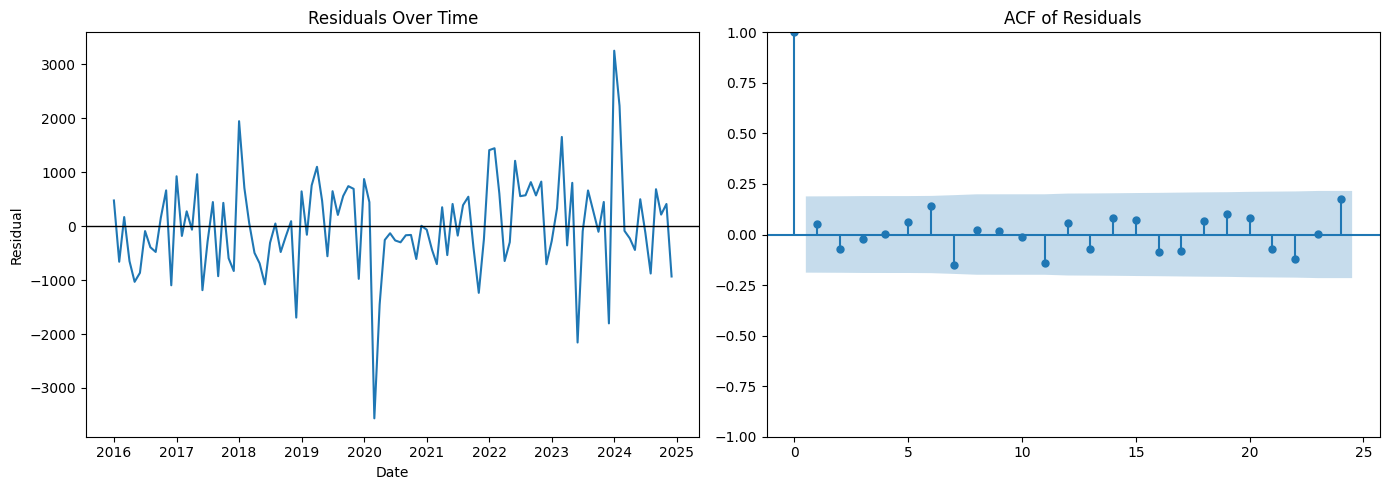

In [38]:
residuals = fit_arimax_lag0.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(residuals.index, residuals.values)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")

plot_acf(residuals, lags=24, ax=axes[1])
axes[1].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()
